<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg" align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">Supervivencia en Cáncer de Mama</p>
<p style="margin: 0; text-align:right;">2026-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
<p style="margin: 0; text-align:right;">Julio Úbeda Quesada</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# Análisis de Supervivencia y Predicción de Riesgo Clínico en Cáncer de Mama

**Notebook específico para el conjunto de datos TCGA-BRCA (`brca_tcga_gdc_clinical_data.tsv`).**

Este cuaderno replica la lógica del notebook de METABRIC y la adapta a la cohorte TCGA:
1. carga y descripción del dataset clínico;
2. EDA reutilizando el módulo `EDA_functions.py`;
3. limpieza orientada a supervivencia;
4. preprocesamiento reproducible para Kaplan-Meier, Cox, Random Survival Forest y DeepSurv.

Para la correcta ejecución del cuaderno necesitaremos importar los siguientes módulos. Las librerías específicas de modelado de supervivencia se importan de forma tolerante: si alguna no está instalada, el preprocesamiento puede ejecutarse igualmente y se mostrará un aviso.

In [1]:
# Sistema
import os
import sys
import re
import warnings
from pathlib import Path

# Ciencia de datos
import numpy as np
import pandas as pd

# Estadística
from scipy import stats
from scipy.stats import wilcoxon
from scipy.stats.mstats import winsorize

# Visualización
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns

# Machine Learning / preprocesamiento
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Persistencia de objetos preprocesados
import joblib

# ── Imports opcionales para modelado de supervivencia ───────────────────────

try:
    from lifelines import KaplanMeierFitter, CoxPHFitter
    from lifelines.statistics import logrank_test, multivariate_logrank_test
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False
    print("⚠ lifelines no está instalado. El preprocesamiento se ejecutará igualmente.")

try:
    from sksurv.ensemble import RandomSurvivalForest
    from sksurv.linear_model import CoxPHSurvivalAnalysis
    from sksurv.metrics import (
        concordance_index_censored,
        concordance_index_ipcw,
        brier_score,
        integrated_brier_score
    )
    from sksurv.util import Surv
    HAS_SKSURV = True
except ImportError:
    HAS_SKSURV = False
    Surv = None
    print("⚠ scikit-survival no está instalado. Se creará un structured array equivalente con numpy.")

try:
    import torch
    import torch.nn as nn
    import torchtuples as tt
    from pycox.models import CoxPH as DeepSurvModel
    HAS_DEEPSURV = True
except ImportError:
    HAS_DEEPSURV = False
    torch = None
    print("⚠ pycox/torchtuples no están instalados. Se prepararán los arrays para DeepSurv.")

# ── Configuración del entorno ────────────────────────────────────────────────

warnings.filterwarnings("ignore")

# Ruta raíz útil en notebooks dentro de /notebooks
root_dir = Path.cwd().resolve().parent
sys.path.append(str(root_dir))

# Configuración de pandas
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

if torch is not None:
    torch.manual_seed(RANDOM_STATE)

print("✓ Imports completados.")
print(f"  lifelines       : {'disponible' if HAS_LIFELINES else 'no disponible'}")
print(f"  scikit-survival : {'disponible' if HAS_SKSURV else 'no disponible'}")
print(f"  DeepSurv/pycox  : {'disponible' if HAS_DEEPSURV else 'no disponible'}")
if torch is not None:
    print(f"  PyTorch         : {torch.__version__}")
    print(f"  CUDA            : {'disponible' if torch.cuda.is_available() else 'no disponible — CPU'}")

✓ Imports completados.
  lifelines       : disponible
  scikit-survival : disponible
  DeepSurv/pycox  : disponible
  PyTorch         : 2.10.0+cpu
  CUDA            : no disponible — CPU


In [2]:
# Importa y actualiza las funciones personalizadas de EDA.
# Compatible tanto con estructura de proyecto:
#   ├── notebooks/TCGA.ipynb
#   └── utils/EDA_functions.py
# como con el notebook y EDA_functions.py en la misma carpeta.

import importlib

candidate_paths = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.cwd().resolve().parent / "utils",
    Path.cwd().resolve() / "utils",
    Path("/mnt/data"),  # útil en este entorno de generación/validación
]

for p in candidate_paths:
    if p.exists() and str(p) not in sys.path:
        sys.path.append(str(p))

try:
    import utils.EDA_functions as eda
except ModuleNotFoundError:
    import EDA_functions as eda

eda = importlib.reload(eda)

print("✓ Módulo EDA importado correctamente.")
print("Funciones reutilizadas:", [f for f in dir(eda) if not f.startswith("_") and callable(getattr(eda, f))])

✓ Módulo EDA importado correctamente.
Funciones reutilizadas: ['describe_df', 'make_subplots', 'null_summary', 'plot_categorical_subplots', 'plot_correlation_heatmap', 'plot_numerical_subplots', 'unique_df']


---
# 1. Estrategia de adquisición de datos de cáncer de mama

Para mantener la trazabilidad con el notebook de METABRIC, se trabaja con la descarga clínica pública de cBioPortal/GDC:

* **TCGA-BRCA:** `brca_tcga_gdc_clinical_data.tsv`

El objetivo del notebook no es entrenar todavía los modelos finales, sino dejar una matriz de covariables y objetivos de supervivencia lista para:

* **Kaplan-Meier:** análisis no paramétrico por grupos clínicos.
* **Cox PH / Cox penalizado:** modelos semiparamétricos.
* **Random Survival Forest:** modelo no lineal basado en árboles.
* **DeepSurv:** red neuronal basada en la pérdida parcial de Cox.

---
# 2. Cargar los datos clínicos

La celda siguiente busca el archivo en varias rutas habituales. Si se ejecuta desde el proyecto, la ruta esperada es `../data/brca_tcga_gdc_clinical_data.tsv`. Si se ejecuta en la misma carpeta que el TSV, también funcionará sin cambios.

In [3]:
DATASET_NAME = "TCGA-BRCA"
DATA_FILE = "brca_tcga_gdc_clinical_data.tsv"

DATA_PATH_CANDIDATES = [
    Path("../data") / DATA_FILE,
    Path("data") / DATA_FILE,
    Path(DATA_FILE),
    Path("/mnt/data") / DATA_FILE,  # útil en este entorno de generación/validación
]

DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No se encontró el archivo brca_tcga_gdc_clinical_data.tsv. "
        "Colócalo en ../data/, en ./data/ o en la misma carpeta del notebook."
    )

tcga_brca = pd.read_csv(DATA_PATH, sep="\t")

print(f"✓ Dataset cargado desde: {DATA_PATH}")
print(f"Dimensiones: {tcga_brca.shape[0]} filas × {tcga_brca.shape[1]} columnas")
tcga_brca.head()

✓ Dataset cargado desde: ..\data\brca_tcga_gdc_clinical_data.tsv
Dimensiones: 1102 filas × 44 columnas


,Study ID,Patient ID,Sample ID,Diagnosis Age,American Joint Committee on Cancer Publication Version Type,Biopsy Site,Cancer Type,Cancer Type Detailed,Last Communication Contact from Initial Pathologic Diagnosis Date,Birth from Initial Pathologic Diagnosis Date,Death from Initial Pathologic Diagnosis Date,Disease Free (Months),Disease Free Status,Disease Type,Ethnicity Category,Fraction Genome Altered,ICD-10 Classification,Is FFPE,Morphology,Mutation Count,Oncotree Code,Overall Survival (Months),Overall Survival Status,Other Patient ID,Other Sample ID,AJCC Pathologic M-Stage,AJCC Pathologic N-Stage,AJCC Pathologic Stage,AJCC Pathologic T-Stage,Primary Diagnosis,Patient Primary Tumor Site,Prior Malignancy,Prior Treatment,Project Identifier,Project Name,Project State,Race Category,Number of Samples Per Patient,Sample Type,Sample type id,Sex,TMB (nonsynonymous),Patient's Vital Status,Year of Diagnosis
0,brca_tcga_gdc,TCGA-3C-AAAU,TCGA-3C-AAAU-01,55.0,6th,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,3767.0,-20211.0,NaN,59.440444,1:Recurred/Progressed,Infiltrating Lobular Carcinoma,NOT HISPANIC OR LATINO,0.7341,C50.9,NO,8520/3,18.0,BRCA,132.950066,0:LIVING,6e7d5ec6-a469-467c-b748-237353c23416,197b76a1-a09a-4659-83aa-2c14fd1023a9,MX,NX,Stage X,TX,Infiltrating Lobular Carcinoma,Breast,False,False,TCGA-BRCA,Invasive Breast Carcinoma,released,WHITE,1,Primary Tumor,1,Female,0.600000,Alive,2004.0
1,brca_tcga_gdc,TCGA-3C-AALI,TCGA-3C-AALI-01,50.0,6th,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,3801.0,-18538.0,NaN,131.669790,0:DiseaseFree,Infiltrating Ductal Carcinoma,NOT HISPANIC OR LATINO,0.7353,C50.9,NO,8500/3,408.0,BRCA,131.570302,0:LIVING,55262fcb-1b01-4480-b322-36570430c917,0050d7c9-ece9-4b6c-8023-1ff2efcb3c9c,M0,N1a,Stage IIB,T2,Infiltrating Ductal Carcinoma,Breast,False,False,TCGA-BRCA,Invasive Breast Carcinoma,released,BLACK OR AFRICAN AMERICAN,1,Primary Tumor,1,Female,13.566667,Alive,2003.0
2,brca_tcga_gdc,TCGA-3C-AALJ,TCGA-3C-AALJ-01,62.0,7th,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,1228.0,-22848.0,NaN,48.459743,0:DiseaseFree,Infiltrating Ductal Carcinoma,NOT HISPANIC OR LATINO,0.5327,C50.9,NO,8500/3,25.0,BRCA,48.423127,0:LIVING,427d0648-3f77-4ffc-b52c-89855426d647,e355913a-6e4c-4d63-8a53-8be4c5b003b8,M0,N1a,Stage IIB,T2,Infiltrating Ductal Carcinoma,Breast,False,False,TCGA-BRCA,Invasive Breast Carcinoma,released,BLACK OR AFRICAN AMERICAN,1,Primary Tumor,1,Female,0.833333,Alive,2011.0
3,brca_tcga_gdc,TCGA-3C-AALK,TCGA-3C-AALK-01,52.0,7th,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,1217.0,-19074.0,NaN,NaN,NaN,Infiltrating Ductal Carcinoma,NOT HISPANIC OR LATINO,0.0921,C50.9,NO,8500/3,40.0,BRCA,47.568988,0:LIVING,c31900a4-5dcd-4022-97ac-638e86e889e4,2a532346-0008-4af8-99bc-d709585da1d6,M0,N0 (i+),Stage IA,T1c,Infiltrating Ductal Carcinoma,Breast,False,False,TCGA-BRCA,Invasive Breast Carcinoma,released,BLACK OR AFRICAN AMERICAN,1,Primary Tumor,1,Female,1.333333,Alive,2011.0
4,brca_tcga_gdc,TCGA-4H-AAAK,TCGA-4H-AAAK-01,50.0,7th,Breast,Invasive Breast Carcinoma,Invasive Breast Carcinoma,158.0,-18371.0,NaN,11.440971,0:DiseaseFree,Infiltrating Lobular Carcinoma,NOT HISPANIC OR LATINO,0.2226,C50.9,NO,8520/3,15.0,BRCA,11.432326,0:LIVING,6623fc5e-00be-4476-967a-cbd55f676ea6,685b5df4-0620-40e2-aa09-0dd736bb5e2b,M0,N2a,Stage IIIA,T2,Infiltrating Lobular Carcinoma,Breast,False,False,TCGA-BRCA,Invasive Breast Carcinoma,released,WHITE,1,Primary Tumor,1,Female,0.500000,Alive,2013.0


---
# **3. Breast Cancer TCGA-BRCA**

## **3.1. Descripción del conjunto de datos**

TCGA-BRCA contiene información clínica, anatomopatológica, genómica agregada y de seguimiento de pacientes con carcinoma invasivo de mama. A diferencia de METABRIC, que suele tener un seguimiento más prolongado, TCGA aporta variables con nomenclatura GDC/AJCC y campos de fechas relativas al diagnóstico.

Puntos críticos para supervivencia:

* `Overall Survival (Months)` define el tiempo hasta muerte o censura.
* `Overall Survival Status` codifica el evento como `0:LIVING` o `1:DECEASED`.
* `Death from Initial Pathologic Diagnosis Date` y `Last Communication Contact from Initial Pathologic Diagnosis Date` no deben usarse como covariables, porque forman parte directa del mecanismo de seguimiento/supervivencia.
* `Disease Free (Months)` y `Disease Free Status` representan otro endpoint clínico; se excluyen del modelo principal de supervivencia global para evitar *data leakage*.

In [4]:
# Resumen general reutilizando el módulo EDA
eda.describe_df(tcga_brca)

Dimensiones del DataFrame: 1102 filas, 44 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,Study ID,object,1102,0.00,1,brca_tcga_gdc (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Patient ID,object,1102,0.00,1095,"TCGA-AC-A6IX (2), TCGA-BH-A18V (2), TCGA-BH-A1ES (2)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Sample ID,object,1102,0.00,1102,"TCGA-3C-AAAU-01 (1), TCGA-3C-AALI-01 (1), TCGA-3C-AALJ-01 (1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Diagnosis Age,float64,1086,1.45,64,None,58.507366,58.000000,13.213993,26.000000,49.000000,68.000000,89.000000
4,American Joint Committee on Cancer Publication Version Type,object,960,12.89,5,"6th (445), 7th (419), 5th (59)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Biopsy Site,object,1101,0.09,1,Breast (1101),NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cancer Type,object,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Cancer Type Detailed,object,1102,0.00,1,Invasive Breast Carcinoma (1102),NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Last Communication Contact from Initial Pathologic Diagnosis Date,float64,994,9.80,647,None,721.242455,359.000000,972.922774,-7.000000,100.250000,1013.000000,7067.000000
9,Birth from Initial Pathologic Diagnosis Date,float64,1086,1.45,1042,None,-21558.522099,-21527.000000,4827.882673,-32873.000000,-24847.750000,-18005.000000,-9706.000000


In [5]:
# Resumen de valores nulos
eda.null_summary(tcga_brca)

,Column,Data Type,Non-null Count,Null Count,% Null Values,TotalCount
0,Death from Initial Pathologic Diagnosis Date,float64,153,949,86.12,1102
1,Ethnicity Category,object,927,175,15.88,1102
2,Disease Free (Months),float64,942,160,14.52,1102
3,Disease Free Status,object,943,159,14.43,1102
4,American Joint Committee on Cancer Publication Version Type,object,960,142,12.89,1102
5,Mutation Count,float64,970,132,11.98,1102
6,TMB (nonsynonymous),float64,971,131,11.89,1102
7,Last Communication Contact from Initial Pathologic Diagnosis Date,float64,994,108,9.80,1102
8,Race Category,object,1006,96,8.71,1102
9,Diagnosis Age,float64,1086,16,1.45,1102


In [6]:
# Duplicados por paciente y granularidad muestra-paciente
n_patients = tcga_brca["Patient ID"].nunique()
n_samples = tcga_brca["Sample ID"].nunique()
n_duplicated_patients = tcga_brca["Patient ID"].duplicated().sum()

print(f"Pacientes únicos : {n_patients}")
print(f"Muestras únicas  : {n_samples}")
print(f"Filas con Patient ID duplicado: {n_duplicated_patients}")

tcga_brca.loc[
    tcga_brca["Patient ID"].duplicated(keep=False),
    ["Patient ID", "Sample ID", "Sample Type", "Sample type id", "Overall Survival (Months)", "Overall Survival Status"]
].sort_values(["Patient ID", "Sample ID"]).head(20)

Pacientes únicos : 1095
Muestras únicas  : 1102
Filas con Patient ID duplicado: 7


,Patient ID,Sample ID,Sample Type,Sample type id,Overall Survival (Months),Overall Survival Status
290,TCGA-AC-A6IX,TCGA-AC-A6IX-01,Primary Tumor,1,12.253614,0:LIVING
291,TCGA-AC-A6IX,TCGA-AC-A6IX-06,Metastatic,6,12.253614,0:LIVING
623,TCGA-BH-A18V,TCGA-BH-A18V-01,Primary Tumor,1,51.116951,1:DECEASED
624,TCGA-BH-A18V,TCGA-BH-A18V-06,Metastatic,6,51.116951,1:DECEASED
627,TCGA-BH-A1ES,TCGA-BH-A1ES-01,Primary Tumor,1,113.731932,1:DECEASED
628,TCGA-BH-A1ES,TCGA-BH-A1ES-06,Metastatic,6,113.731932,1:DECEASED
643,TCGA-BH-A1FE,TCGA-BH-A1FE-01,Primary Tumor,1,74.671485,1:DECEASED
644,TCGA-BH-A1FE,TCGA-BH-A1FE-06,Metastatic,6,74.671485,1:DECEASED
831,TCGA-E2-A15A,TCGA-E2-A15A-01,Primary Tumor,1,23.324573,0:LIVING
832,TCGA-E2-A15A,TCGA-E2-A15A-06,Metastatic,6,23.324573,0:LIVING


**Decisión de granularidad:** para los modelos de supervivencia se utilizará una única fila por paciente. Si un paciente tiene muestra primaria y metastásica, se conserva la muestra `Primary Tumor`, porque el objetivo es construir modelos comparables con METABRIC y orientados a predicción desde datos de diagnóstico/tumor primario.

## **3.2. Análisis estadístico básico**

El EDA se organiza por familias lógicas de variables. Las funciones gráficas se reutilizan desde `EDA_functions.py`:

* `plot_categorical_subplots`
* `plot_numerical_subplots`
* `plot_correlation_heatmap`

In [7]:
# Directorios de salida para los gráficos de EDA
# Se prioriza la estructura del proyecto (../images/EDA/TCGA) y,
# si no hay permisos, se usa una carpeta local junto al notebook.
preferred_eda_output = Path("../images/EDA/TCGA")
fallback_eda_output = Path("images/EDA/TCGA")

try:
    preferred_eda_output.mkdir(parents=True, exist_ok=True)
    EDA_OUTPUT_PATH = preferred_eda_output
except OSError as exc:
    print(f"⚠ No se pudo crear {preferred_eda_output} ({exc}). Se usará {fallback_eda_output}.")
    fallback_eda_output.mkdir(parents=True, exist_ok=True)
    EDA_OUTPUT_PATH = fallback_eda_output

print(f"Los gráficos HTML/PNG se guardarán en: {EDA_OUTPUT_PATH.resolve()}")

Los gráficos HTML/PNG se guardarán en: C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\images\EDA\TCGA


### **3.2.1. Análisis de Variables Categóricas: Distribución y Tendencias**

#### **A. Identificadores y metadatos del estudio**

Estas variables ayudan a validar procedencia, granularidad y homogeneidad del dataset, pero en general no serán utilizadas como predictores.

In [8]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Study ID",
        "Cancer Type",
        "Cancer Type Detailed",
        "Project Identifier",
        "Project State",
        "Sample Type",
        "Is FFPE",
        "Sex"
    ])],
    group_name="Identificadores y Metadatos del Estudio",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=3
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_cat_Identificadores_y_Metadatos_del_Estudio.html


#### **B. Perfil clínico-demográfico**

Incluye edad, sexo, raza y etnicidad. Estas variables pueden ser relevantes tanto para describir la cohorte como para ajustar modelos multivariantes.

In [9]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Race Category",
        "Ethnicity Category",
        "Sex",
        "Prior Malignancy",
        "Prior Treatment"
    ])],
    group_name="Perfil Clínico-Demográfico",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=3
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_cat_Perfil_Clínico-Demográfico.html


#### **C. Caracterización histológica y patológica**

Agrupa la clasificación tumoral, el diagnóstico primario y las categorías AJCC. Estas variables serán candidatas importantes para los modelos de Cox, RSF y DeepSurv.

In [10]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Disease Type",
        "Primary Diagnosis",
        "AJCC Pathologic Stage",
        "AJCC Pathologic T-Stage",
        "AJCC Pathologic N-Stage",
        "AJCC Pathologic M-Stage"
    ])],
    group_name="Caracterización Histológica y Estadificación AJCC",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=3
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_cat_Caracterización_Histológica_y_Estadificación_AJCC.html


#### **D. Variables de estado de supervivencia y progresión**

Estas variables describen los endpoints clínicos. Para el modelo principal se utilizará supervivencia global; las variables de progresión/recaída se reservarán para análisis secundarios.

In [11]:
eda.plot_categorical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Overall Survival Status",
        "Patient's Vital Status",
        "Disease Free Status"
    ])],
    group_name="Variables de Estado de Supervivencia",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=3
)

✔ Categorical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_cat_Variables_de_Estado_de_Supervivencia.html


### **3.2.2. Análisis de Variables Numéricas: Distribución y Tendencias**

#### **A. Demografía, diagnóstico y seguimiento**

`Diagnosis Age` es una covariable basal interpretable. Las fechas relativas al diagnóstico sirven para entender el seguimiento, pero no deben incluirse como predictores si codifican directamente censura o muerte.

In [12]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Diagnosis Age",
        "Birth from Initial Pathologic Diagnosis Date",
        "Year of Diagnosis",
        "Last Communication Contact from Initial Pathologic Diagnosis Date",
        "Death from Initial Pathologic Diagnosis Date"
    ])],
    group_name="Demografía y Fechas Relativas al Diagnóstico",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=3
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_num_subplots_Demografía_y_Fechas_Relativas_al_Diagnóstico.html


#### **B. Métricas de supervivencia y progresión**

`Overall Survival (Months)` es el tiempo principal del análisis. `Disease Free (Months)` pertenece a otro endpoint y se excluye del modelo principal de OS.

In [13]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Overall Survival (Months)",
        "Disease Free (Months)"
    ])],
    group_name="Métricas Temporales de Supervivencia",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_num_subplots_Métricas_Temporales_de_Supervivencia.html


#### **C. Métricas genómicas agregadas**

`Mutation Count`, `TMB (nonsynonymous)` y `Fraction Genome Altered` resumen carga mutacional y alteración genómica. En el preprocesamiento se conserva `Mutation Count` y se elimina `TMB (nonsynonymous)` por redundancia casi perfecta.

In [14]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Fraction Genome Altered",
        "Mutation Count",
        "TMB (nonsynonymous)"
    ])],
    group_name="Métricas Genómicas Agregadas",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=3
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_num_subplots_Métricas_Genómicas_Agregadas.html


#### **D. Variables de estructura muestral**

Estas columnas describen la estructura muestra-paciente. Son útiles para auditoría de duplicados, pero no se incorporan como covariables.

In [15]:
eda.plot_numerical_subplots(
    df=tcga_brca.loc[:, tcga_brca.columns.isin([
        "Number of Samples Per Patient",
        "Sample type id"
    ])],
    group_name="Variables de Estructura Muestral",
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    ncol=2
)

✔ Numerical subplots guardado en: ..\images\EDA\TCGA\TCGA-BRCA_num_subplots_Variables_de_Estructura_Muestral.html


### **3.2.3. Análisis de Correlaciones**

Se calcula un mapa de correlaciones sobre variables numéricas relevantes. Este paso es especialmente importante para detectar redundancias y posibles fugas de información.

✔ Heatmap guardado en: ..\images\EDA\TCGA\TCGA-BRCA_heatmap_correlaciones.png


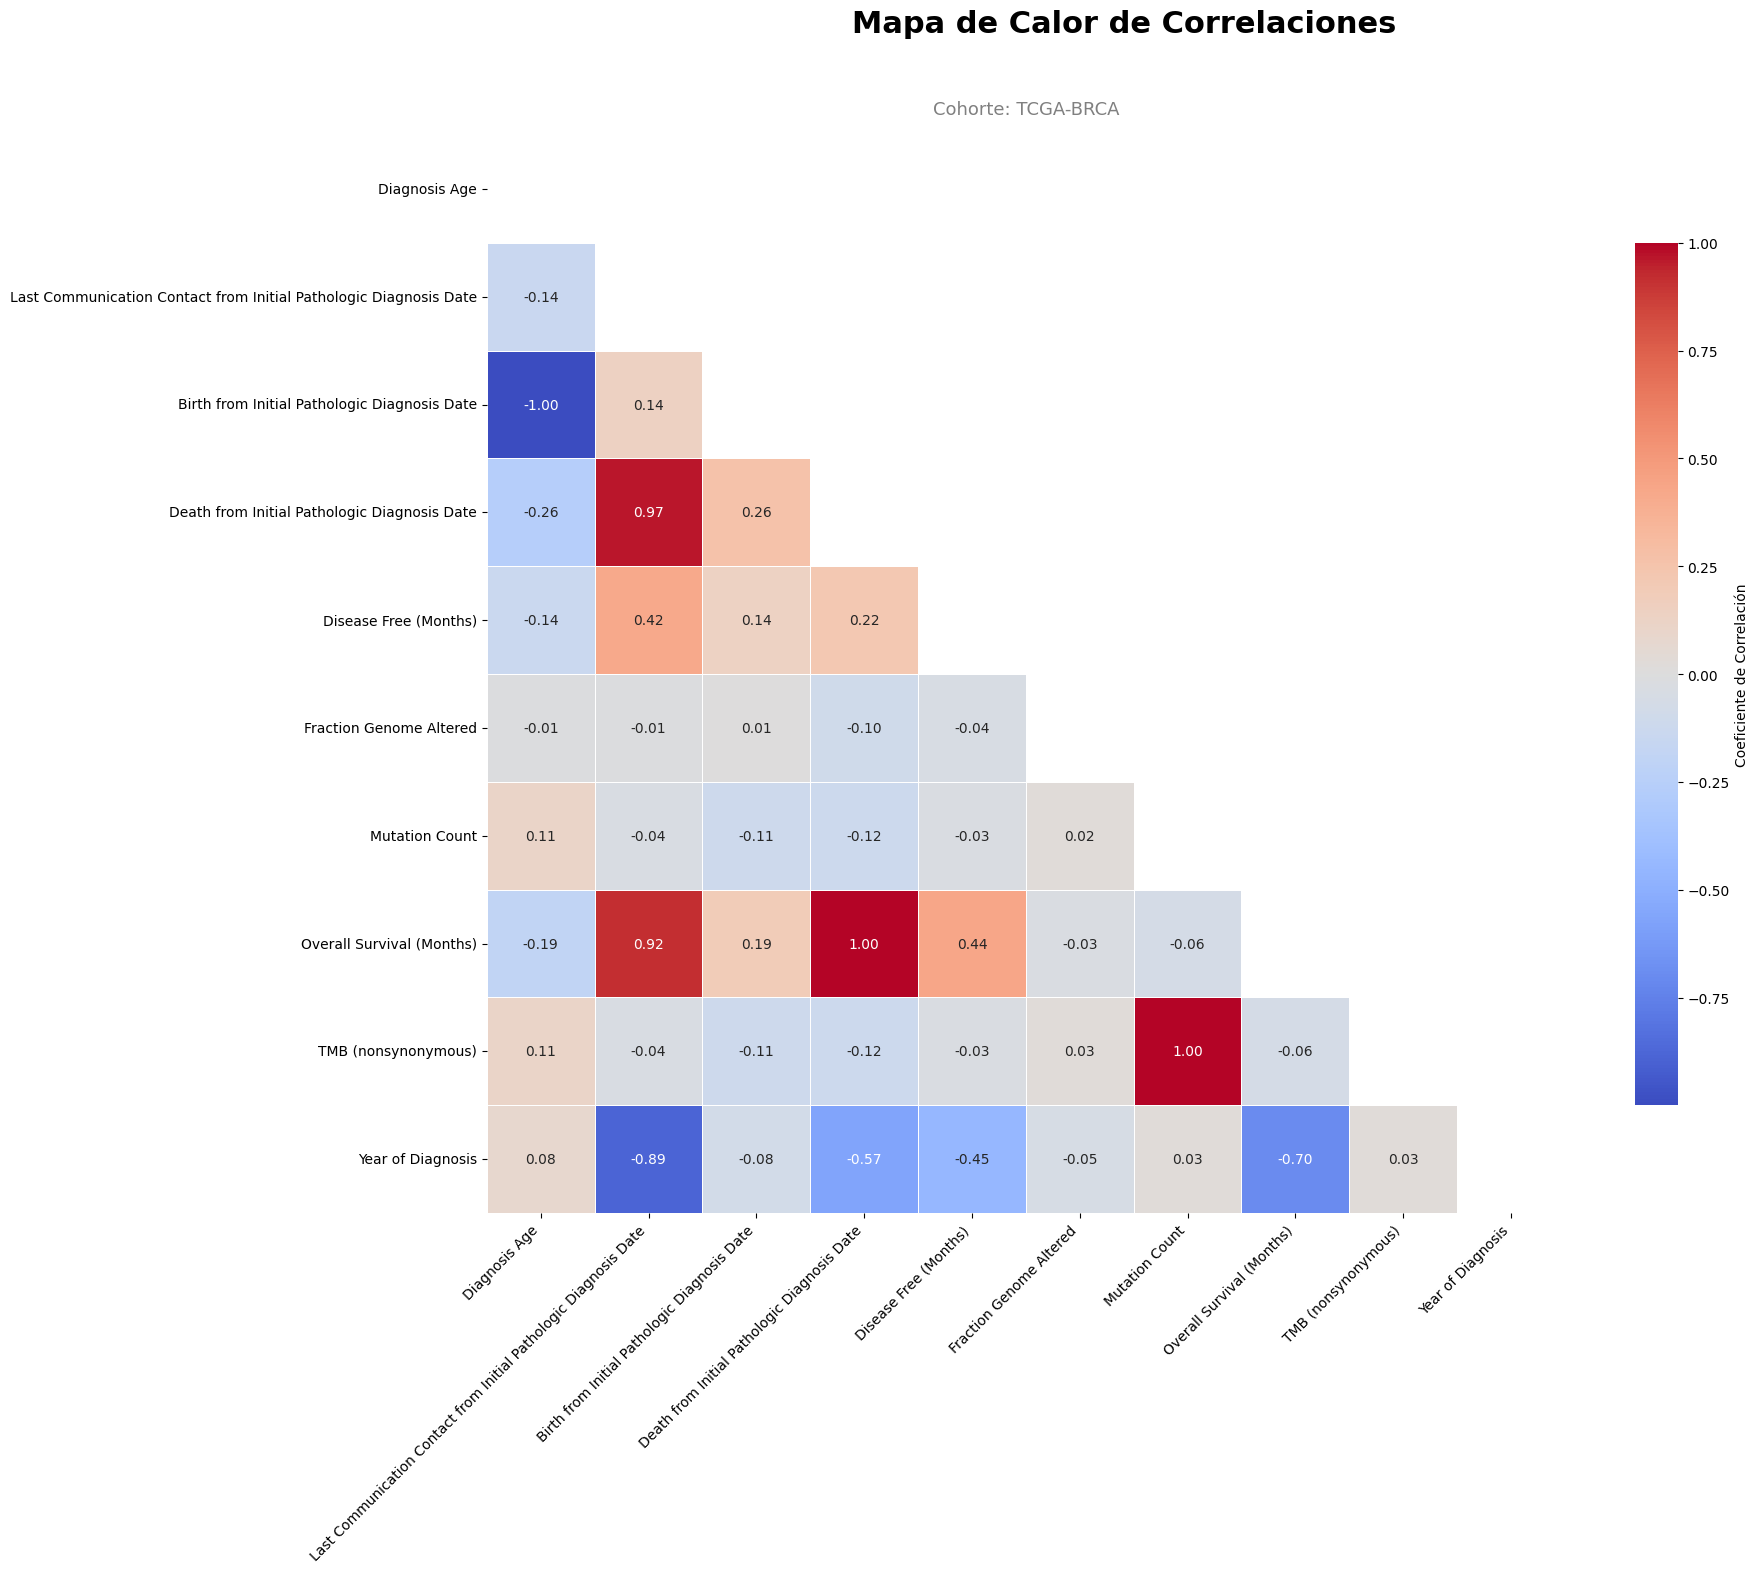


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Resumen de Correlaciones — TCGA-BRCA (Pearson)
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  Etiqueta   Par de variables                                                                                                      Corr
  ────────── ────────────────────────────────────────────────────────────────────────────────────────────────────────────────── ───────
  ▲ Top 1    Overall Survival (Months)  ↔  Death from Initial Pathologic Diagnosis Date                                          1.0000
  ▲ Top 2    TMB (nonsynonymous)  ↔  Mutation Count                                                                              0.9999
  ▲ Top 3    Death from Initial Pathologic Diagnosis Date  ↔  Last Communication Contact from Initial Pathologic Diagnosis Date  0.9682
  ▲ 

In [16]:
NUMERIC_CORR_COLS = [
    "Diagnosis Age",
    "Birth from Initial Pathologic Diagnosis Date",
    "Year of Diagnosis",
    "Last Communication Contact from Initial Pathologic Diagnosis Date",
    "Death from Initial Pathologic Diagnosis Date",
    "Disease Free (Months)",
    "Fraction Genome Altered",
    "Mutation Count",
    "TMB (nonsynonymous)",
    "Overall Survival (Months)"
]

eda.plot_correlation_heatmap(
    df=tcga_brca.loc[:, tcga_brca.columns.isin(NUMERIC_CORR_COLS)],
    dataset_name=DATASET_NAME,
    output_path=str(EDA_OUTPUT_PATH),
    top_n=8
)

**Lectura esperada del heatmap antes del modelado:**

* `Death from Initial Pathologic Diagnosis Date` es prácticamente equivalente a `Overall Survival (Months)` en pacientes fallecidos, por lo que no puede entrar como covariable.
* `Last Communication Contact from Initial Pathologic Diagnosis Date` codifica seguimiento/censura y también debe excluirse.
* `Birth from Initial Pathologic Diagnosis Date` es redundante con `Diagnosis Age`.
* `TMB (nonsynonymous)` y `Mutation Count` miden casi el mismo fenómeno; se conserva `Mutation Count`.
* `Disease Free (Months)` es un endpoint alternativo y no debe utilizarse para predecir supervivencia global.

---
## **3.3. Preprocesado de los datos**

El preprocesamiento está diseñado para producir objetos reutilizables en cuatro familias de modelos:

* **Kaplan-Meier:** `km_df`, con `duration`, `event` y grupos clínicos.
* **Cox / lifelines:** `cox_train_df` y `cox_test_df`.
* **RSF / scikit-survival:** `X_train`, `X_test`, `y_train`, `y_test`.
* **DeepSurv / pycox:** `X_train_deepsurv`, `X_test_deepsurv`, `dur_*`, `evt_*`.

In [17]:
# Trabajamos sobre una copia para no modificar el DataFrame del EDA
tcga_prep = tcga_brca.copy()

print(f"Shape inicial: {tcga_prep.shape}")

Shape inicial: (1102, 44)


### **3.3.1. Selección de una muestra primaria por paciente**

TCGA-BRCA contiene algunos pacientes con más de una muestra. Para evitar que un mismo paciente aparezca varias veces en train/test, se priorizan las muestras `Primary Tumor` y se conserva una única fila por `Patient ID`.

In [18]:
n_antes = len(tcga_prep)

if {"Patient ID", "Sample Type"}.issubset(tcga_prep.columns):
    tcga_prep["__sample_priority"] = np.where(tcga_prep["Sample Type"].eq("Primary Tumor"), 0, 1)
    tcga_prep = (
        tcga_prep
        .sort_values(["Patient ID", "__sample_priority"])
        .drop_duplicates(subset=["Patient ID"], keep="first")
        .drop(columns="__sample_priority")
    )

print(f"Registros eliminados por duplicidad muestra-paciente: {n_antes - len(tcga_prep)}")
print(f"Shape resultante: {tcga_prep.shape}")
print("\nDistribución de Sample Type tras deduplicar:")
display(tcga_prep["Sample Type"].value_counts(dropna=False).to_frame("n"))

Registros eliminados por duplicidad muestra-paciente: 7
Shape resultante: (1095, 44)

Distribución de Sample Type tras deduplicar:


,n
Sample Type,
Primary Tumor,1095


### **3.3.2. Eliminación de columnas de metadatos, identificadores y constantes**

Se eliminan identificadores únicos, constantes de estudio/proyecto y variables de estructura muestral. Estas columnas no aportan señal clínica generalizable y pueden introducir ruido o sobreajuste.

In [19]:
COLS_DROP_METADATA = [
    # Identificadores únicos o casi únicos
    "Patient ID",
    "Sample ID",
    "Other Patient ID",
    "Other Sample ID",

    # Metadatos de estudio/proyecto
    "Study ID",
    "Project Identifier",
    "Project Name",
    "Project State",

    # Constantes o casi constantes en TCGA-BRCA
    "Cancer Type",
    "Cancer Type Detailed",
    "Oncotree Code",
    "Biopsy Site",
    "Patient Primary Tumor Site",
    "Is FFPE",

    # Estructura muestral
    "Number of Samples Per Patient",
    "Sample Type",
    "Sample type id",

    # Codificaciones auxiliares de diagnóstico
    "ICD-10 Classification",
    "Morphology",

    # Variable de codificación/versión, no característica biológica del paciente
    "American Joint Committee on Cancer Publication Version Type",

    # Potencial proxy de calendario/seguimiento, no predictor clínico basal robusto
    "Year of Diagnosis",
]

cols_present = [c for c in COLS_DROP_METADATA if c in tcga_prep.columns]
tcga_prep.drop(columns=COLS_DROP_METADATA, inplace=True, errors="ignore")

print(f"Columnas eliminadas ({len(cols_present)}): {cols_present}")
print(f"Shape resultante: {tcga_prep.shape}")

Columnas eliminadas (21): ['Patient ID', 'Sample ID', 'Other Patient ID', 'Other Sample ID', 'Study ID', 'Project Identifier', 'Project Name', 'Project State', 'Cancer Type', 'Cancer Type Detailed', 'Oncotree Code', 'Biopsy Site', 'Patient Primary Tumor Site', 'Is FFPE', 'Number of Samples Per Patient', 'Sample Type', 'Sample type id', 'ICD-10 Classification', 'Morphology', 'American Joint Committee on Cancer Publication Version Type', 'Year of Diagnosis']
Shape resultante: (1095, 23)


### **3.3.3. Eliminación de variables redundantes o con fuga de información**

Se excluyen variables que duplican la variable objetivo, codifican seguimiento posterior al diagnóstico o representan endpoints alternativos:

* `Patient's Vital Status` duplica `Overall Survival Status`.
* `Death from Initial Pathologic Diagnosis Date` y `Last Communication Contact from Initial Pathologic Diagnosis Date` forman parte del cálculo del seguimiento.
* `Birth from Initial Pathologic Diagnosis Date` duplica la edad al diagnóstico.
* `TMB (nonsynonymous)` es redundante con `Mutation Count`.
* `Primary Diagnosis` duplica conceptualmente `Disease Type`.
* `Disease Free (Months)` y `Disease Free Status` corresponden al endpoint de progresión/recaída.

In [20]:
COLS_REDUNDANTES = [
    "Patient's Vital Status",
    "Death from Initial Pathologic Diagnosis Date",
    "Last Communication Contact from Initial Pathologic Diagnosis Date",
    "Birth from Initial Pathologic Diagnosis Date",
    "TMB (nonsynonymous)",
    "Primary Diagnosis",
]

COLS_LEAKAGE = [
    "Disease Free (Months)",
    "Disease Free Status",
]

COLS_REDUNDANTES_LEAKAGE = COLS_REDUNDANTES + COLS_LEAKAGE

cols_present = [c for c in COLS_REDUNDANTES_LEAKAGE if c in tcga_prep.columns]
tcga_prep.drop(columns=COLS_REDUNDANTES_LEAKAGE, inplace=True, errors="ignore")

print(f"Columnas eliminadas ({len(cols_present)}): {cols_present}")
print(f"Shape resultante: {tcga_prep.shape}")

Columnas eliminadas (8): ["Patient's Vital Status", 'Death from Initial Pathologic Diagnosis Date', 'Last Communication Contact from Initial Pathologic Diagnosis Date', 'Birth from Initial Pathologic Diagnosis Date', 'TMB (nonsynonymous)', 'Primary Diagnosis', 'Disease Free (Months)', 'Disease Free Status']
Shape resultante: (1095, 15)


### **3.3.4. Definición y parsing de las variables objetivo (`duration` y `event`)**

Todos los modelos de supervivencia requieren:

* `duration`: tiempo de seguimiento en meses.
* `event`: indicador binario donde `1`/`True` representa muerte y `0`/`False` representa censura.

En TCGA-BRCA, `Overall Survival Status` está codificada como `0:LIVING` y `1:DECEASED`. Se extrae el primer dígito para obtener el indicador de evento.

In [21]:
tcga_prep["duration"] = tcga_prep["Overall Survival (Months)"].copy()

tcga_prep["event"] = (
    tcga_prep["Overall Survival Status"]
    .astype(str)
    .str.extract(r"^(\d)")[0]
    .astype(float)
)

TARGET_COLS = ["duration", "event"]

# Verificación del objetivo
eda.describe_df(tcga_prep[TARGET_COLS])

Dimensiones del DataFrame: 1095 filas, 2 columnas



,Column,Data Type,Non-null Count,% Null Values,Unique Values,TopCounts,mean,median,std,min,25%,75%,max
0,duration,float64,1094,0.09,825,None,40.341896,26.954665,39.072175,-0.229961,14.495729,54.870237,282.687254
1,event,float64,1094,0.09,2,None,0.138026,0.000000,0.345085,0.000000,0.000000,0.000000,1.000000


In [22]:
print(f"Columnas objetivo creadas ({len(TARGET_COLS)}): {TARGET_COLS}")
print(f"Shape resultante: {tcga_prep.shape}")

print("\nDistribución del evento:")
display(tcga_prep["event"].value_counts(dropna=False).to_frame("n"))

event_rate = tcga_prep["event"].mean(skipna=True)
print(f"Tasa de eventos observada: {event_rate:.2%}")

Columnas objetivo creadas (2): ['duration', 'event']
Shape resultante: (1095, 17)

Distribución del evento:


,n
event,
0.0,943
1.0,151
NaN,1


Tasa de eventos observada: 13.80%


### **3.3.5. Eliminación de registros con valores nulos en las variables objetivo**

Imputar tiempo de supervivencia o estado vital no es metodológicamente aceptable, porque implicaría inventar cuándo ocurrió el evento o si ocurrió. Se eliminan únicamente los registros sin `duration` o sin `event`.

In [23]:
n_antes = len(tcga_prep)

tcga_prep.dropna(subset=["duration", "event"], inplace=True)

COLS_POST_TARGET = [
    "Overall Survival (Months)",
    "Overall Survival Status",
]

tcga_prep.drop(columns=COLS_POST_TARGET, inplace=True, errors="ignore")

print(f"Columnas eliminadas tras crear target ({len(COLS_POST_TARGET)}): {COLS_POST_TARGET}")
print(f"Shape resultante: {tcga_prep.shape}")
print(f"\nRegistros eliminados: {n_antes - len(tcga_prep)} ({(n_antes - len(tcga_prep)) / n_antes:.2%})")
print(f"Registros restantes : {len(tcga_prep)}")

Columnas eliminadas tras crear target (2): ['Overall Survival (Months)', 'Overall Survival Status']
Shape resultante: (1094, 15)

Registros eliminados: 1 (0.09%)
Registros restantes : 1094


### **3.3.6. Tratamiento de tiempos de supervivencia en cero**

Los tiempos `T = 0` pueden causar problemas numéricos en modelos basados en Cox y en algunos algoritmos de supervivencia. Se corrigen a un valor mínimo positivo (`0.001` meses) sin eliminar registros.

In [24]:
EPSILON = 0.001

n_ceros = (tcga_prep["duration"] == 0).sum()
tcga_prep["duration"] = tcga_prep["duration"].clip(lower=EPSILON)

print(f"Registros con T=0 corregidos : {n_ceros}")
print(f"Tiempo mínimo tras corrección: {tcga_prep['duration'].min():.4f} meses")
print(f"Tiempo máximo                : {tcga_prep['duration'].max():.2f} meses")

Registros con T=0 corregidos : 20
Tiempo mínimo tras corrección: 0.0010 meses
Tiempo máximo                : 282.69 meses


### **3.3.7. Dataset auxiliar para Kaplan-Meier**

Kaplan-Meier no requiere matriz de covariables codificada. Para los análisis estratificados se conserva una tabla compacta con el objetivo y algunas variables clínicas interpretables.

In [25]:
KM_GROUP_COLS = [
    "AJCC Pathologic Stage",
    "AJCC Pathologic T-Stage",
    "AJCC Pathologic N-Stage",
    "AJCC Pathologic M-Stage",
    "Disease Type",
    "Race Category",
    "Sex",
    "Diagnosis Age",
]

km_cols_present = TARGET_COLS + [c for c in KM_GROUP_COLS if c in tcga_prep.columns]
km_df = tcga_prep[km_cols_present].copy()

if "Diagnosis Age" in km_df.columns:
    km_df["Age Group"] = pd.cut(
        km_df["Diagnosis Age"],
        bins=[0, 50, 65, np.inf],
        labels=["<50", "50-65", ">65"],
        right=False
    )

print(f"Shape km_df: {km_df.shape}")
km_df.head()

Shape km_df: (1094, 11)


,duration,event,AJCC Pathologic Stage,AJCC Pathologic T-Stage,AJCC Pathologic N-Stage,AJCC Pathologic M-Stage,Disease Type,Race Category,Sex,Diagnosis Age,Age Group
0,132.950066,0.0,Stage X,TX,NX,MX,Infiltrating Lobular Carcinoma,WHITE,Female,55.0,50-65
1,131.570302,0.0,Stage IIB,T2,N1a,M0,Infiltrating Ductal Carcinoma,BLACK OR AFRICAN AMERICAN,Female,50.0,50-65
2,48.423127,0.0,Stage IIB,T2,N1a,M0,Infiltrating Ductal Carcinoma,BLACK OR AFRICAN AMERICAN,Female,62.0,50-65
3,47.568988,0.0,Stage IA,T1c,N0 (i+),M0,Infiltrating Ductal Carcinoma,BLACK OR AFRICAN AMERICAN,Female,52.0,50-65
4,11.432326,0.0,Stage IIIA,T2,N2a,M0,Infiltrating Lobular Carcinoma,WHITE,Female,50.0,50-65


### **3.3.8. Selección del subconjunto de covariables para el modelado**

Una vez eliminado el objetivo original y las columnas con fuga de información, las covariables restantes quedan como candidatas para Cox, RSF y DeepSurv.

In [26]:
FEATURE_COLS = [c for c in tcga_prep.columns if c not in TARGET_COLS]

print(f"Covariables candidatas ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  - {c}")

print(f"\nShape resultante: {tcga_prep.shape}")

Covariables candidatas (13):
  - Diagnosis Age
  - Disease Type
  - Ethnicity Category
  - Fraction Genome Altered
  - Mutation Count
  - AJCC Pathologic M-Stage
  - AJCC Pathologic N-Stage
  - AJCC Pathologic Stage
  - AJCC Pathologic T-Stage
  - Prior Malignancy
  - Prior Treatment
  - Race Category
  - Sex

Shape resultante: (1094, 15)


### **3.3.9. División estratificada en conjuntos train/test**

Se usa una partición 80/20 estratificada por evento. Esto es importante porque la tasa de eventos en TCGA-BRCA es relativamente baja, y una partición aleatoria simple podría producir un test set con muy pocos eventos.

In [27]:
X = tcga_prep[FEATURE_COLS].copy()
y_duration = tcga_prep["duration"].astype(float).values
y_event = tcga_prep["event"].astype(int).values

X_train, X_test, dur_train, dur_test, evt_train, evt_test = train_test_split(
    X,
    y_duration,
    y_event,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_event
)

print(f"Train: {len(X_train)} registros | Tasa de eventos: {evt_train.mean():.2%}")
print(f"Test : {len(X_test)} registros | Tasa de eventos: {evt_test.mean():.2%}")

Train: 875 registros | Tasa de eventos: 13.83%
Test : 219 registros | Tasa de eventos: 13.70%


### **3.3.10. Imputación de valores nulos en covariables**

La estrategia reproduce el enfoque de METABRIC:

* Variables numéricas → mediana calculada solo en train.
* Variables categóricas → categoría explícita `"Unknown"`.

Después de imputar las categóricas, se convierten a string para evitar errores de `OneHotEncoder` cuando una columna mezcla booleanos (`True`/`False`) con `"Unknown"`.

In [28]:
NUM_COLS = X_train.select_dtypes(include="number").columns.tolist()
CAT_COLS = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print(f"Variables numéricas ({len(NUM_COLS)}): {NUM_COLS}")
print(f"\nVariables categóricas ({len(CAT_COLS)}): {CAT_COLS}")

Variables numéricas (3): ['Diagnosis Age', 'Fraction Genome Altered', 'Mutation Count']

Variables categóricas (10): ['Disease Type', 'Ethnicity Category', 'AJCC Pathologic M-Stage', 'AJCC Pathologic N-Stage', 'AJCC Pathologic Stage', 'AJCC Pathologic T-Stage', 'Prior Malignancy', 'Prior Treatment', 'Race Category', 'Sex']


In [29]:
imputer_num = SimpleImputer(strategy="median")
imputer_cat = SimpleImputer(strategy="constant", fill_value="Unknown")

if NUM_COLS:
    X_train[NUM_COLS] = imputer_num.fit_transform(X_train[NUM_COLS])
    X_test[NUM_COLS] = imputer_num.transform(X_test[NUM_COLS])

if CAT_COLS:
    X_train[CAT_COLS] = imputer_cat.fit_transform(X_train[CAT_COLS])
    X_test[CAT_COLS] = imputer_cat.transform(X_test[CAT_COLS])

    # Evita mezcla de tipos boolean/string tras imputación
    X_train[CAT_COLS] = X_train[CAT_COLS].astype(str)
    X_test[CAT_COLS] = X_test[CAT_COLS].astype(str)

print("Nulos tras imputación:")
print(f"  X_train: {X_train.isna().sum().sum()}")
print(f"  X_test : {X_test.isna().sum().sum()}")

Nulos tras imputación:
  X_train: 0
  X_test : 0


### **3.3.11. Tratamiento de outliers en variables numéricas continuas**

Se aplica winsorización empírica al percentil 1–99, calculando los umbrales únicamente en train y aplicándolos a train/test. Esta decisión reduce el impacto de valores extremos en Cox y DeepSurv sin eliminar observaciones.

In [30]:
COLS_WINSORIZE = [
    "Diagnosis Age",
    "Fraction Genome Altered",
    "Mutation Count",
]

winsor_limits = {}

for col in COLS_WINSORIZE:
    if col in X_train.columns:
        p01 = np.percentile(X_train[col].astype(float), 1)
        p99 = np.percentile(X_train[col].astype(float), 99)
        winsor_limits[col] = (p01, p99)

        X_train[col] = X_train[col].clip(lower=p01, upper=p99)
        X_test[col] = X_test[col].clip(lower=p01, upper=p99)

        print(f"{col:<30} -> clipped a [{p01:.4f}, {p99:.4f}]")

Diagnosis Age                  -> clipped a [30.7400, 89.0000]
Fraction Genome Altered        -> clipped a [0.0001, 0.9024]
Mutation Count                 -> clipped a [8.0000, 711.6200]


### **3.3.12. Codificación de variables categóricas**

Cox, RSF y DeepSurv requieren entradas numéricas. Se usa One-Hot Encoding con:

* `drop='first'` para reducir multicolinealidad perfecta.
* `handle_unknown='ignore'` para tolerar categorías nuevas en test.

> El encoder se ajusta solo sobre train.

In [31]:
try:
    encoder = OneHotEncoder(
        drop="first",
        sparse_output=False,
        handle_unknown="ignore",
        dtype=float
    )
except TypeError:
    # Compatibilidad con versiones antiguas de scikit-learn
    encoder = OneHotEncoder(
        drop="first",
        sparse=False,
        handle_unknown="ignore",
        dtype=float
    )

if CAT_COLS:
    # Ajustar y transformar
    ohe_train = encoder.fit_transform(X_train[CAT_COLS])
    ohe_test = encoder.transform(X_test[CAT_COLS])

    # Nombres de las nuevas columnas
    ohe_feature_names = encoder.get_feature_names_out(CAT_COLS).tolist()

    # Construir DataFrames con columnas OHE
    ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
    ohe_test_df = pd.DataFrame(ohe_test, columns=ohe_feature_names, index=X_test.index)

    # Reemplazar categóricas originales por OHE
    X_train = pd.concat([X_train.drop(columns=CAT_COLS), ohe_train_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=CAT_COLS), ohe_test_df], axis=1)
else:
    ohe_feature_names = []

print(f"Shape X_train tras OHE: {X_train.shape}")
print(f"Shape X_test tras OHE : {X_test.shape}")
print(f"Total covariables finales: {X_train.shape[1]}")

Shape X_train tras OHE: (875, 62)
Shape X_test tras OHE : (219, 62)
Total covariables finales: 62


### **3.3.13. Escalado de variables numéricas**

Se aplica `StandardScaler` solo sobre las variables numéricas originales. Aunque RSF no requiere escalado, mantener un pipeline homogéneo facilita la comparación con Cox y DeepSurv.

In [32]:
scaler = StandardScaler()

if NUM_COLS:
    X_train[NUM_COLS] = scaler.fit_transform(X_train[NUM_COLS])
    X_test[NUM_COLS] = scaler.transform(X_test[NUM_COLS])

print(f"Variables escaladas ({len(NUM_COLS)}): {NUM_COLS}")

if NUM_COLS:
    display(eda.describe_df(X_train[NUM_COLS])[["Column", "mean", "std"]])

Variables escaladas (3): ['Diagnosis Age', 'Fraction Genome Altered', 'Mutation Count']
Dimensiones del DataFrame: 875 filas, 3 columnas



,Column,mean,std
0,Diagnosis Age,2.070725e-16,1.000572
1,Fraction Genome Altered,8.120488e-17,1.000572
2,Mutation Count,-6.597897e-17,1.000572


### **3.3.14. Creación del `structured array` de scikit-survival**

`scikit-survival` espera un array estructurado con dos campos:

* `event`: booleano.
* `time`: tiempo de seguimiento.

Si `scikit-survival` está instalado, se usa `Surv.from_arrays`. Si no lo está, se crea un array equivalente con `numpy`.

In [33]:
if HAS_SKSURV and Surv is not None:
    y_train = Surv.from_arrays(
        event=evt_train.astype(bool),
        time=dur_train.astype(float)
    )

    y_test = Surv.from_arrays(
        event=evt_test.astype(bool),
        time=dur_test.astype(float)
    )
else:
    y_train = np.array(
        list(zip(evt_train.astype(bool), dur_train.astype(float))),
        dtype=[("event", "?"), ("time", "<f8")]
    )

    y_test = np.array(
        list(zip(evt_test.astype(bool), dur_test.astype(float))),
        dtype=[("event", "?"), ("time", "<f8")]
    )

print(f"y_train dtype: {y_train.dtype} | shape: {y_train.shape}")
print(f"y_test dtype : {y_test.dtype} | shape: {y_test.shape}")

y_train dtype: [('event', '?'), ('time', '<f8')] | shape: (875,)
y_test dtype : [('event', '?'), ('time', '<f8')] | shape: (219,)


### **3.3.15. Objetos finales para Cox, RSF y DeepSurv**

Se crean vistas específicas para cada familia de modelos:

* `cox_train_df`, `cox_test_df`: formato cómodo para `lifelines.CoxPHFitter`.
* `X_train`, `X_test`, `y_train`, `y_test`: formato para `scikit-survival`.
* `X_train_deepsurv`, `X_test_deepsurv`, `dur_*_deepsurv`, `evt_*_deepsurv`: arrays `float32` para `pycox`.

In [34]:
# Arrays numpy generales
X_train_np = X_train.values.astype(float)
X_test_np = X_test.values.astype(float)

# DataFrames para lifelines / CoxPHFitter
cox_train_df = X_train.copy()
cox_train_df["duration"] = dur_train.astype(float)
cox_train_df["event"] = evt_train.astype(int)

cox_test_df = X_test.copy()
cox_test_df["duration"] = dur_test.astype(float)
cox_test_df["event"] = evt_test.astype(int)

# Arrays para DeepSurv / pycox
X_train_deepsurv = X_train_np.astype("float32")
X_test_deepsurv = X_test_np.astype("float32")
dur_train_deepsurv = dur_train.astype("float32")
dur_test_deepsurv = dur_test.astype("float32")
evt_train_deepsurv = evt_train.astype("float32")
evt_test_deepsurv = evt_test.astype("float32")

print(f"X_train_np        : {X_train_np.shape}")
print(f"X_test_np         : {X_test_np.shape}")
print(f"cox_train_df      : {cox_train_df.shape}")
print(f"cox_test_df       : {cox_test_df.shape}")
print(f"X_train_deepsurv  : {X_train_deepsurv.shape} | dtype: {X_train_deepsurv.dtype}")
print(f"X_test_deepsurv   : {X_test_deepsurv.shape} | dtype: {X_test_deepsurv.dtype}")

print("\nValidación de nulos:")
print(f"  X_train: {np.isnan(X_train_np).sum()}")
print(f"  X_test : {np.isnan(X_test_np).sum()}")

X_train_np        : (875, 62)
X_test_np         : (219, 62)
cox_train_df      : (875, 64)
cox_test_df       : (219, 64)
X_train_deepsurv  : (875, 62) | dtype: float32
X_test_deepsurv   : (219, 62) | dtype: float32

Validación de nulos:
  X_train: 0
  X_test : 0


### **3.3.16. Comprobaciones finales de coherencia**

Antes de entrenar modelos, se comprueba:

* igualdad de columnas entre train/test;
* ausencia de valores nulos;
* duración positiva;
* tasa de eventos preservada por la estratificación.

In [35]:
assert list(X_train.columns) == list(X_test.columns), "Train/test no tienen las mismas columnas."
assert np.isfinite(X_train_np).all(), "X_train contiene valores no finitos."
assert np.isfinite(X_test_np).all(), "X_test contiene valores no finitos."
assert (dur_train > 0).all() and (dur_test > 0).all(), "Hay duraciones no positivas."

summary_preproc = pd.DataFrame({
    "split": ["train", "test"],
    "n": [len(X_train), len(X_test)],
    "events": [int(evt_train.sum()), int(evt_test.sum())],
    "event_rate": [evt_train.mean(), evt_test.mean()],
    "median_duration": [np.median(dur_train), np.median(dur_test)],
    "n_features": [X_train.shape[1], X_test.shape[1]]
})

summary_preproc

,split,n,events,event_rate,median_duration,n_features
0,train,875,121,0.138286,27.496715,62
1,test,219,30,0.136986,24.770039,62


### **3.3.17. Guardado opcional de objetos preprocesados**

Esta celda guarda los objetos necesarios para reutilizarlos en notebooks de modelado. Si no quieres persistir nada, puedes omitirla.

In [36]:
preferred_processed_output = Path("../data/processed")
fallback_processed_output = Path("data/processed")

try:
    preferred_processed_output.mkdir(parents=True, exist_ok=True)
    PROCESSED_OUTPUT_PATH = preferred_processed_output
except OSError as exc:
    print(f"⚠ No se pudo crear {preferred_processed_output} ({exc}). Se usará {fallback_processed_output}.")
    fallback_processed_output.mkdir(parents=True, exist_ok=True)
    PROCESSED_OUTPUT_PATH = fallback_processed_output

processed_bundle = {
    "dataset_name": DATASET_NAME,
    "random_state": RANDOM_STATE,
    "feature_cols_raw": FEATURE_COLS,
    "num_cols": NUM_COLS,
    "cat_cols": CAT_COLS,
    "ohe_feature_names": ohe_feature_names,
    "final_feature_names": X_train.columns.tolist(),
    "winsor_limits": winsor_limits,
    "imputer_num": imputer_num,
    "imputer_cat": imputer_cat,
    "encoder": encoder,
    "scaler": scaler,
    "km_df": km_df,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "dur_train": dur_train,
    "dur_test": dur_test,
    "evt_train": evt_train,
    "evt_test": evt_test,
    "cox_train_df": cox_train_df,
    "cox_test_df": cox_test_df,
    "X_train_deepsurv": X_train_deepsurv,
    "X_test_deepsurv": X_test_deepsurv,
    "dur_train_deepsurv": dur_train_deepsurv,
    "dur_test_deepsurv": dur_test_deepsurv,
    "evt_train_deepsurv": evt_train_deepsurv,
    "evt_test_deepsurv": evt_test_deepsurv,
}

bundle_path = PROCESSED_OUTPUT_PATH / "tcga_brca_survival_preprocessed.joblib"
features_path = PROCESSED_OUTPUT_PATH / "tcga_brca_final_features.csv"
summary_path = PROCESSED_OUTPUT_PATH / "tcga_brca_preprocessing_summary.csv"

joblib.dump(processed_bundle, bundle_path)
pd.Series(X_train.columns, name="feature").to_csv(features_path, index=False)
summary_preproc.to_csv(summary_path, index=False)

print(f"✓ Bundle guardado en : {bundle_path.resolve()}")
print(f"✓ Features guardadas: {features_path.resolve()}")
print(f"✓ Resumen guardado   : {summary_path.resolve()}")

✓ Bundle guardado en : C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\processed\tcga_brca_survival_preprocessed.joblib
✓ Features guardadas: C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\processed\tcga_brca_final_features.csv
✓ Resumen guardado   : C:\Users\usuario\Documents\GitHub\TFM---Analisis-de-supervivencia-del-cancer\Modulo 3 - Diseño e implementacion del trabajo\data\processed\tcga_brca_preprocessing_summary.csv


---
# 4. Siguiente paso: implementación de modelos

A partir de este punto, los objetos preparados pueden conectarse directamente con los notebooks de modelado:

```python
# Kaplan-Meier
# km_df[['duration', 'event', 'AJCC Pathologic Stage', 'Age Group', ...]]

# Cox con lifelines
# cph = CoxPHFitter(penalizer=0.01)
# cph.fit(cox_train_df, duration_col='duration', event_col='event')

# Random Survival Forest con scikit-survival
# rsf = RandomSurvivalForest(random_state=RANDOM_STATE)
# rsf.fit(X_train, y_train)

# DeepSurv con pycox
# net = ...
# model = DeepSurvModel(net, tt.optim.Adam)
# model.fit(X_train_deepsurv, (dur_train_deepsurv, evt_train_deepsurv), ...)
```

Este notebook deja documentadas las decisiones de limpieza para que los resultados de Kaplan-Meier, Cox, RSF y DeepSurv sean comparables con los obtenidos en METABRIC.